# Vocabulary Level Prediction
## EDA

## 0. Enviorment Setting

In [1]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import utils
from sklearn.model_selection import train_test_split
importlib.reload(utils)  # Pick up changes to utils.py without restarting the kernel
from utils import (apply_preprocessing_to_dataframe, get_missing_counts, get_target_value_counts,
    compute_rater_agreement, plot_target_distributions_side_by_side, plot_absolute_difference_distribution,
    get_text_length_features_df, get_length_features_summary, plot_length_distributions,
    plot_feature_distribution, get_length_target_correlations, plot_length_target_heatmap,
    get_vocabulary_richness_df, get_richness_features_summary, plot_richness_distributions,
    get_top_n_words_corpus, get_top_n_words_per_score_group, get_top_n_ngrams_corpus,
    get_top_ngrams_by_absolute_correlation, get_ngram_presence_matrix,
    plot_top_ngrams_bar, get_pos_ratios_df, get_readability_features_df,
    get_essay_embeddings, get_embedding_pca_2d, plot_embedding_scatter_2d,
    get_embedding_kmeans_labels, get_cluster_space_2d, plot_cluster_space_score_labels, 
    get_cluster_target_summary, get_handcrafted_feature_ranked_correlations,
)

# Show full column content when displaying DataFrames
pd.set_option("display.max_colwidth", None)

c:\Users\gilad\CursorProjects\Vocabulary Level Prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Preprocessing

In [2]:
# Read vocabulary dataset (text_id, Text, vocabulary1, vocabulary2)
df = pd.read_csv("vocabulary_data.csv")

# Show a few rows with Text column in full (no truncation)
pd.set_option("display.max_colwidth", None)
# df.head(5)

In [3]:
# Apply preprocessing (normalize whitespace, lowercase, strip punctuation keep . ? !)
df = apply_preprocessing_to_dataframe(df, "Text", output_column="Text_cleaned")
# df[["text_id", "Text_cleaned", "Vocabulary_1", "Vocabulary_2"]].head(5)

In [4]:
# Split to 80% train / 20% test; EDA and modeling use only the train set.
import os
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df = df_train  # From here on, df is the train set (EDA and modeling). df_test held out for evaluation.
print(f"Train: {len(df)} rows, Test: {len(df_test)} rows")

# Save train and test to CSV in Data/ for use in Model_selection notebook
os.makedirs("Data", exist_ok=True)
df_train.to_csv("Data/train.csv", index=False)
df_test.to_csv("Data/test.csv", index=False)

Train: 7112 rows, Test: 1778 rows


## 2. EDA

### 2.1 Basic statistics and target definition

In [5]:
# Missing values per column
get_missing_counts(df)

text_id         1926
Text               0
Vocabulary_1       0
Vocabulary_2       0
Text_cleaned       0
dtype: int64

In [6]:
# Target distributions (Vocabulary_1, Vocabulary_2)
get_target_value_counts(df, "Vocabulary_1")

Vocabulary_1
0      14
1      14
2     836
3    3834
4    2127
5     287
Name: count, dtype: int64

In [7]:
get_target_value_counts(df, "Vocabulary_2")

Vocabulary_2
0      14
1      18
2     845
3    3926
4    2049
5     260
Name: count, dtype: int64

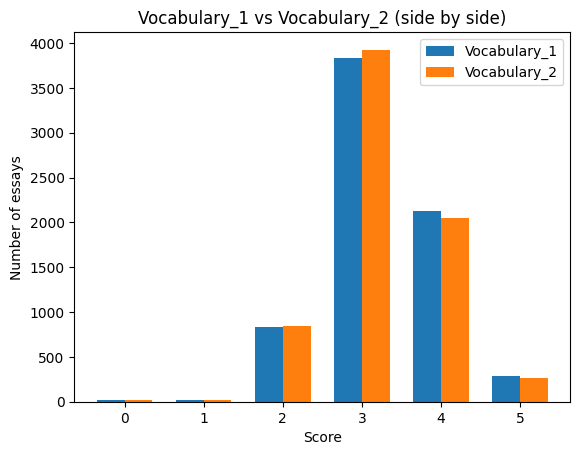

In [8]:
# Target distributions side by side (Vocabulary_1 vs Vocabulary_2 per score 0-5)
plot_target_distributions_side_by_side(df, "Vocabulary_1", "Vocabulary_2")
plt.show()

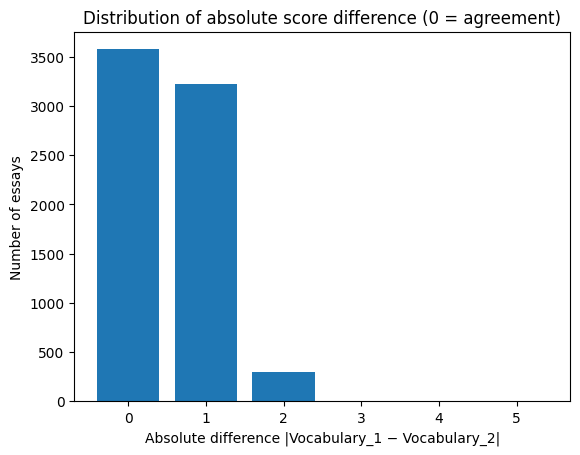

In [9]:
# Distribution of absolute score difference (0 = agreement, 1-5 = disagreement)
plot_absolute_difference_distribution(df, "Vocabulary_1", "Vocabulary_2")
plt.show()

In [10]:
# V1 vs V2 scatter
# Rater agreement: weighted kappa, exact agreement %, Spearman correlation
compute_rater_agreement(df, "Vocabulary_1", "Vocabulary_2")

{'weighted_kappa': 0.4080955447434579,
 'exact_agreement_pct': np.float64(50.309336332958374),
 'spearman_corr': np.float64(0.3802229250717624)}

### 2.2 Text length analysis

In [11]:
# Per-essay length features from Text_cleaned (char, word, sentence count, avg word length)
length_features = get_text_length_features_df(df, "Text_cleaned")

get_length_features_summary(length_features)

,char_count,word_count,sentence_count,avg_word_length
mean,2276.528121,428.825647,18.606159,4.328725
std,1038.712839,197.505354,10.623283,0.612552
min,1.000000,1.000000,1.000000,1.000000
25%,1536.000000,289.000000,11.000000,4.121523
50%,2117.500000,398.000000,17.000000,4.308683
75%,2822.250000,529.000000,25.000000,4.502999
max,6080.000000,1274.000000,114.000000,42.666667


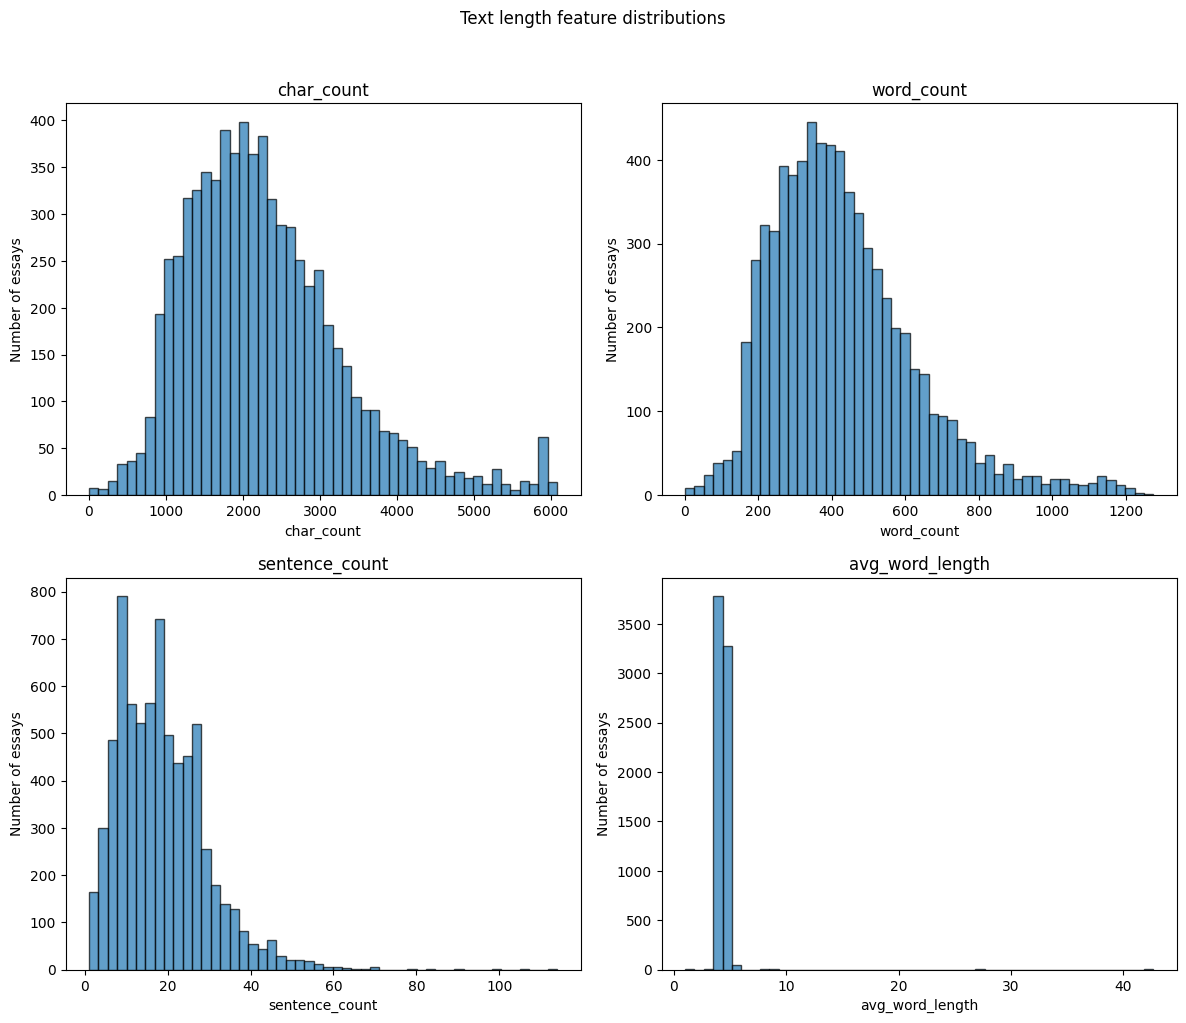

In [12]:
# Distributions of length features (histograms)
plot_length_distributions(length_features)
plt.show()

In [13]:
# Spearman correlation of each length feature with Vocabulary_1 and Vocabulary_2
get_length_target_correlations(length_features, df["Vocabulary_1"], method="spearman")
get_length_target_correlations(length_features, df["Vocabulary_2"], method="spearman")

char_count         0.288554
word_count         0.268695
sentence_count     0.290548
avg_word_length    0.189495
dtype: float64

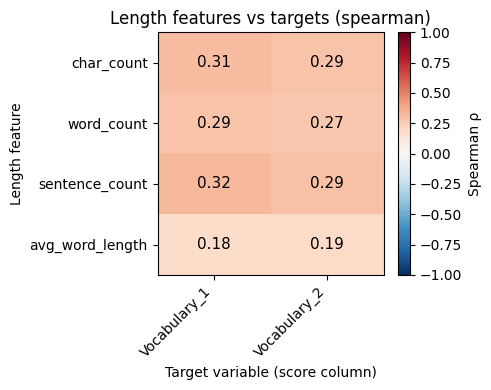

In [14]:
# Heatmap: length features vs target columns (Spearman)
plot_length_target_heatmap(length_features, ["Vocabulary_1", "Vocabulary_2"], df, method="spearman")
plt.tight_layout()
plt.show()

### 2.3 Vocabulary richness

In [15]:
# Per-essay vocabulary richness (unique words, TTR, hapax ratio); . ? ! stripped on demand
richness_features = get_vocabulary_richness_df(df, "Text_cleaned")
get_richness_features_summary(richness_features)

,unique_words,ttr,hapax_ratio
mean,151.777278,0.379599,0.539660
std,53.269877,0.086406,0.077296
min,0.000000,0.000000,0.000000
25%,113.000000,0.320456,0.491071
50%,145.000000,0.372715,0.538972
75%,182.000000,0.431458,0.588718
max,410.000000,1.000000,1.000000


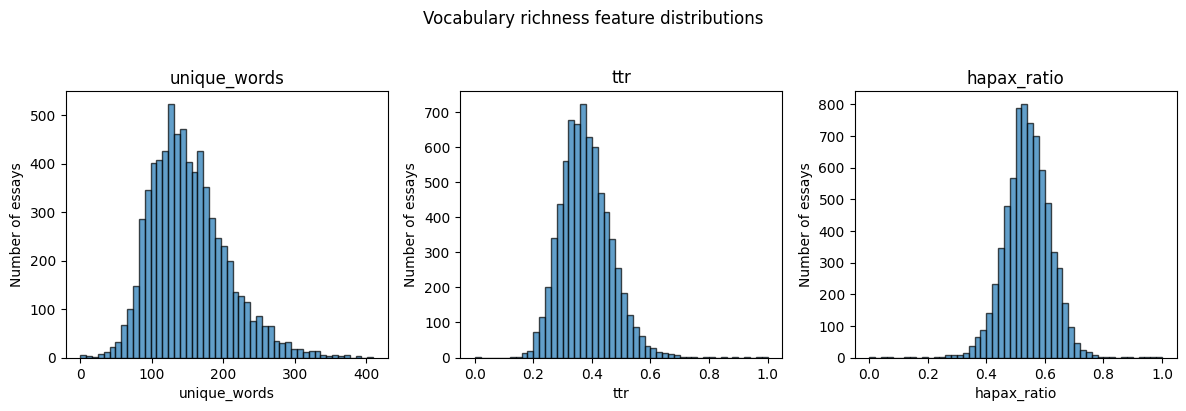

In [16]:
# Distributions of richness features
plot_richness_distributions(richness_features)
plt.show()

In [17]:
# Spearman correlation of each richness feature with Vocabulary_1 and Vocabulary_2
get_length_target_correlations(richness_features, df["Vocabulary_1"], method="spearman")
get_length_target_correlations(richness_features, df["Vocabulary_2"], method="spearman")

unique_words    0.343492
ttr            -0.012597
hapax_ratio     0.064578
dtype: float64

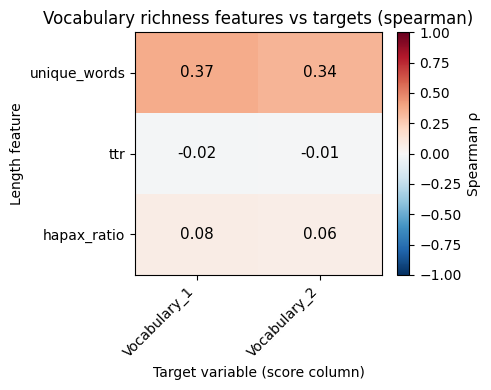

In [18]:
# Heatmap: richness features vs target columns (Spearman)
plot_length_target_heatmap(richness_features, ["Vocabulary_1", "Vocabulary_2"], df, method="spearman", title="Vocabulary richness features vs targets (spearman)")
plt.tight_layout()
plt.show()

### 2.4 Word frequency

In [19]:
# Top 30 words in the corpus (stopwords removed)
top_30_corpus = get_top_n_words_corpus(df["Text_cleaned"], n=10)
top_30_corpus

you         69032
i           42520
can         32757
people      27883
do          25519
students    23709
school      22538
we          20607
your        19563
their       19363
dtype: int64

In [20]:
# Top 30 words per Vocabulary_1 score (0–5); stopwords removed
top_per_score = get_top_n_words_per_score_group(
    df, "Text_cleaned", "Vocabulary_1", n=10
)
for score in sorted(top_per_score.keys()):
    print(f"--- Score {score} ---")
    display(top_per_score[score])

--- Score 0 ---


que       65
i         53
dont      31
my        25
music     24
church    23
para      23
de        22
really    20
por       19
dtype: int64

--- Score 1 ---


you        53
i          44
class      35
success    29
failure    29
good       28
school     26
time       24
work       24
que        24
dtype: int64

--- Score 2 ---


...

you         37494
i           21779
can         17948
people      14598
do          13967
school      11940
students    11862
we          11168
your        10525
their        9282
dtype: int64

--- Score 4 ---


you         21856
i           13928
can          9967
people       9009
students     8878
do           7849
their        7603
school       7422
your         6317
we           6217
dtype: int64

--- Score 5 ---


you         2494
i           2209
can         1470
students    1298
people      1241
their       1201
school      1030
do          1009
my           902
your         807
dtype: int64

### 2.5 N-gram analysis (sentence-bound)

Bigrams and trigrams are computed **within sentences only** (no cross-sentence sequences).  
- **Plot 1:** Top 10 bigrams (overall corpus).  
- **Plot 2:** Top 10 trigrams (overall corpus).  
- **Plot 3 (Option A):** N-gram presence vs target — top 10 positive and top 10 negative Spearman correlations for Vocabulary_1, then for Vocabulary_2.

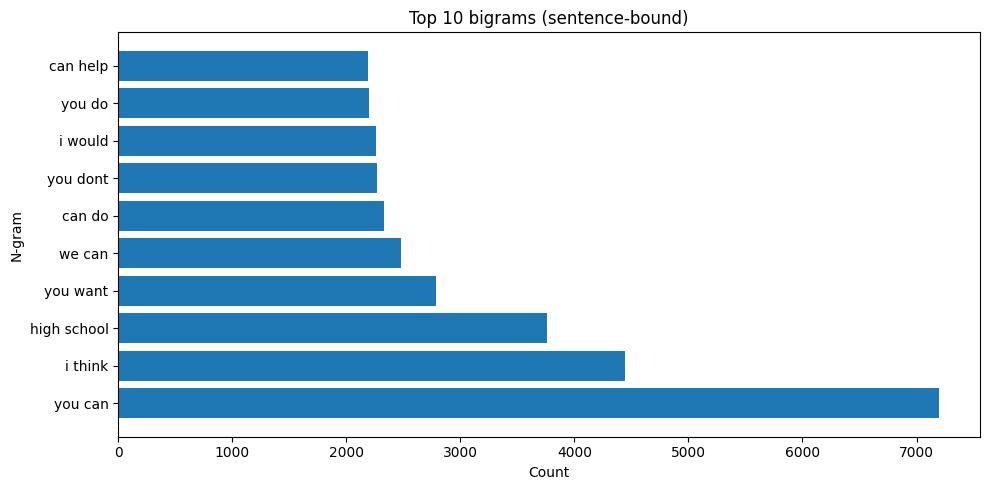

In [21]:
# Top 10 bigrams (overall corpus, sentence-bound; stopwords removed)
top_bigrams = get_top_n_ngrams_corpus(df["Text_cleaned"], n=10, ngram_size=2)
plot_top_ngrams_bar(top_bigrams, "Top 10 bigrams (sentence-bound)", top_n=10, xlabel="Count", figsize=(10, 5))
plt.tight_layout()
plt.show()

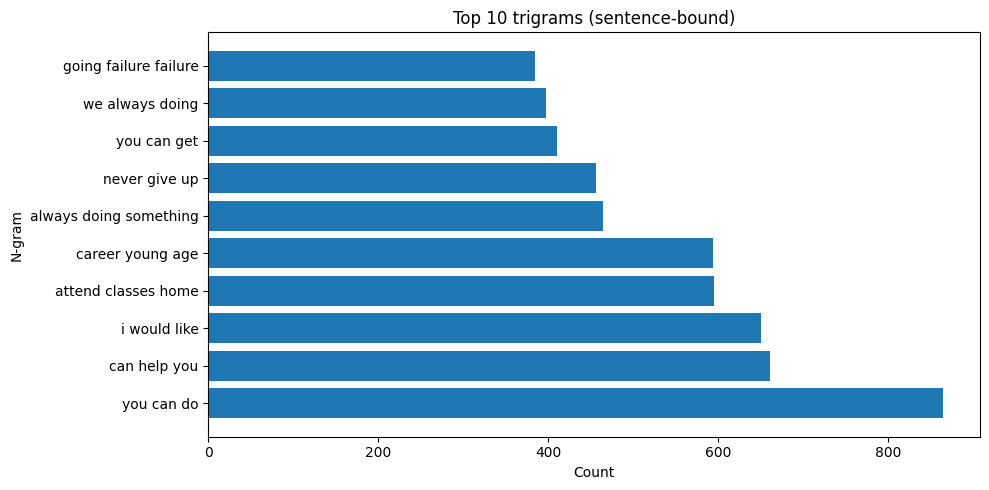

In [22]:
# Top 10 trigrams (overall corpus, sentence-bound; stopwords removed)
top_trigrams = get_top_n_ngrams_corpus(df["Text_cleaned"], n=10, ngram_size=3)
plot_top_ngrams_bar(top_trigrams, "Top 10 trigrams (sentence-bound)", top_n=10, xlabel="Count", figsize=(10, 5))
plt.tight_layout()
plt.show()

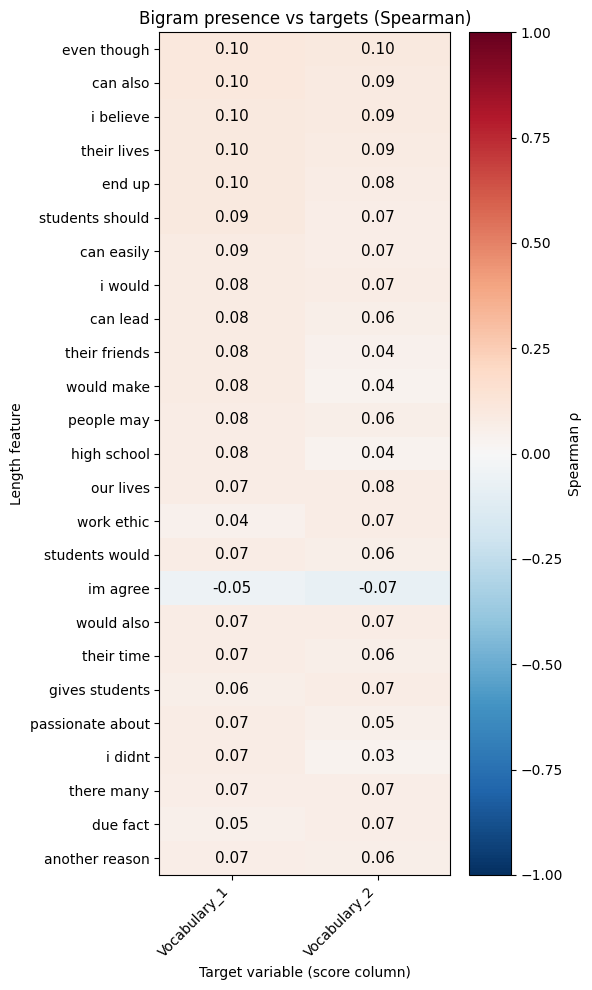

In [23]:
# Heatmap: bigram presence (0/1) vs Vocabulary_1 and Vocabulary_2 (Spearman)
top_bigrams = get_top_ngrams_by_absolute_correlation(df, "Text_cleaned", ["Vocabulary_1", "Vocabulary_2"], ngram_size=2, top_k=25, min_doc_count=2)
presence_bigrams = get_ngram_presence_matrix(df, "Text_cleaned", ngram_size=2, ngram_list=top_bigrams)
plot_length_target_heatmap(
    presence_bigrams,
    ["Vocabulary_1", "Vocabulary_2"],
    df,
    method="spearman",
    title="Bigram presence vs targets (Spearman)",
    figsize=(6, 10),
)
plt.tight_layout()
plt.show()

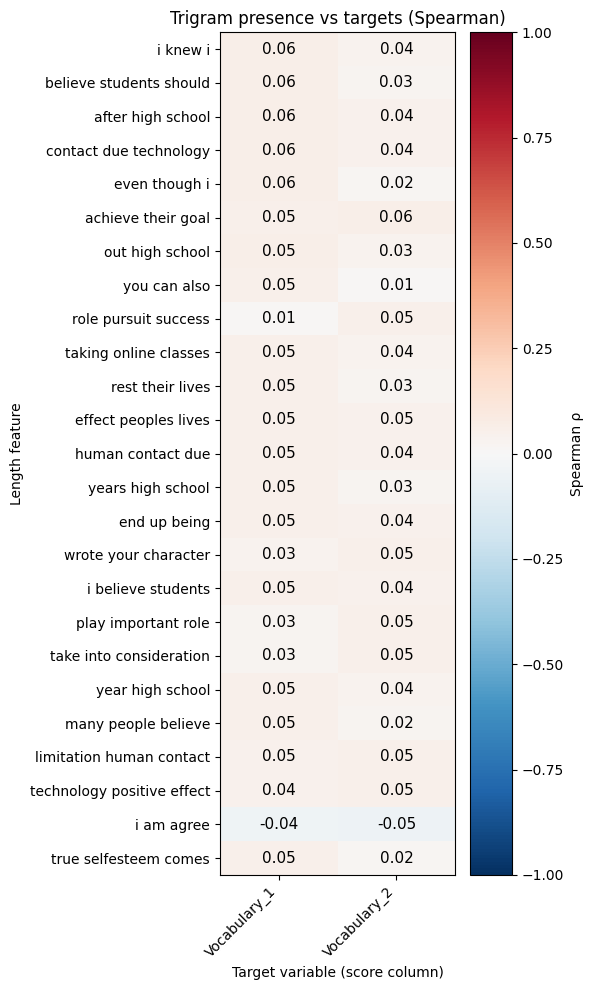

In [24]:
# Heatmap: trigram presence (0/1) vs Vocabulary_1 and Vocabulary_2 (Spearman)
top_trigrams = get_top_ngrams_by_absolute_correlation(df, "Text_cleaned", ["Vocabulary_1", "Vocabulary_2"], ngram_size=3, top_k=25, min_doc_count=2)
presence_trigrams = get_ngram_presence_matrix(df, "Text_cleaned", ngram_size=3, ngram_list=top_trigrams)
plot_length_target_heatmap(
    presence_trigrams,
    ["Vocabulary_1", "Vocabulary_2"],
    df,
    method="spearman",
    title="Trigram presence vs targets (Spearman)",
    figsize=(6, 10),
)
plt.tight_layout()
plt.show()

### 2.6 POS tagging

Part-of-speech ratios per essay (noun, verb, adjective, adverb, other) and their correlation with Vocabulary_1 and Vocabulary_2.

In [25]:
# POS ratios per essay (NLTK Penn Treebank)
pos_ratios = get_pos_ratios_df(df, "Text_cleaned")
pos_ratios.describe()

,noun_ratio,verb_ratio,adj_ratio,adv_ratio,other_ratio
count,7110.000000,7110.000000,7110.000000,7110.000000,7110.000000
mean,0.219230,0.213423,0.078366,0.052547,0.436433
std,0.044839,0.029052,0.023509,0.019385,0.039562
min,0.075342,0.000000,0.000000,0.000000,0.000000
25%,0.190172,0.194651,0.062027,0.039261,0.412468
50%,0.216667,0.213115,0.076264,0.051146,0.437086
75%,0.245380,0.232360,0.092259,0.064815,0.462182
max,1.000000,0.363014,0.190311,0.171779,0.593381


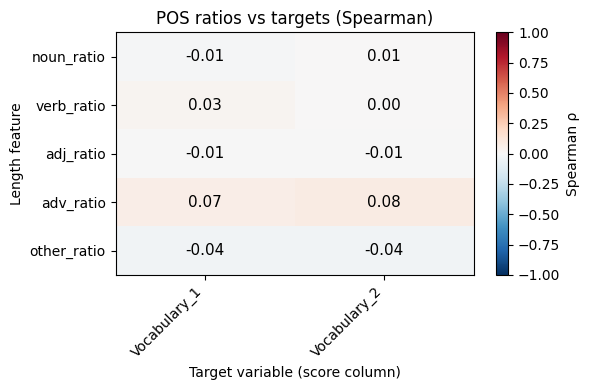

In [26]:
# Heatmap: POS ratios vs Vocabulary_1 and Vocabulary_2 (Spearman)
plot_length_target_heatmap(
    pos_ratios,
    ["Vocabulary_1", "Vocabulary_2"],
    df,
    method="spearman",
    title="POS ratios vs targets (Spearman)",
    figsize=(6, 4),
)
plt.tight_layout()
plt.show()

### 2.7 Readability

Flesch–Kincaid grade level and Flesch Reading Ease per essay, and their correlation with the vocabulary targets.

In [27]:
# Readability features per essay
readability_df = get_readability_features_df(df, "Text_cleaned")
readability_df.describe()

,flesch_kincaid_grade,flesch_reading_ease
count,7112.000000,7112.000000
mean,12.132082,60.690399
std,11.530983,31.586785
min,0.000000,-686.257500
25%,7.693288,56.351253
50%,9.705134,65.850773
75%,12.979909,73.225233
max,287.716059,103.379091


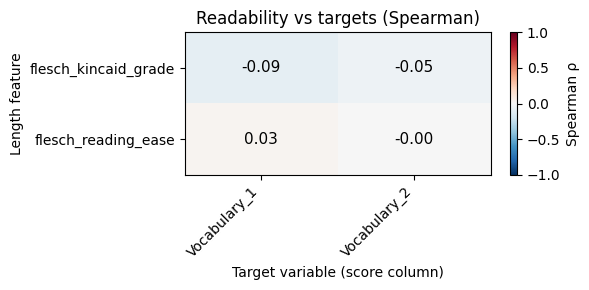

In [28]:
# Heatmap: readability vs Vocabulary_1 and Vocabulary_2 (Spearman)
plot_length_target_heatmap(
    readability_df,
    ["Vocabulary_1", "Vocabulary_2"],
    df,
    method="spearman",
    title="Readability vs targets (Spearman)",
    figsize=(6, 3),
)
plt.tight_layout()
plt.show()

### 2.8 Sentence embeddings + PCA

One vector per essay (sentence-split, embed each sentence, mean-pool). Regular PCA: top 500 components by variance (PC1, PC2, …); 2D = (PC1, PC2); scatter and heatmap of component scores vs Vocabulary_1 and Vocabulary_2.

In [29]:
# Embeddings + 2D from top-k components by correlation (gene-expression style)
embeddings = get_essay_embeddings(df, "Text_cleaned", use_fast_model=True)
pca_obj, X_2d, pca_corr, pca_scores_top = get_embedding_pca_2d(
    embeddings, df, ["Vocabulary_1", "Vocabulary_2"], top_k=500
)
print(f"Embeddings shape: {embeddings.shape}, PCA 2D shape: {X_2d.shape}")

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 3240.71it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L3-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 517/517 [09:16<00:00,  1.08s/it]


Embeddings shape: (7112, 384), PCA 2D shape: (7112, 2)


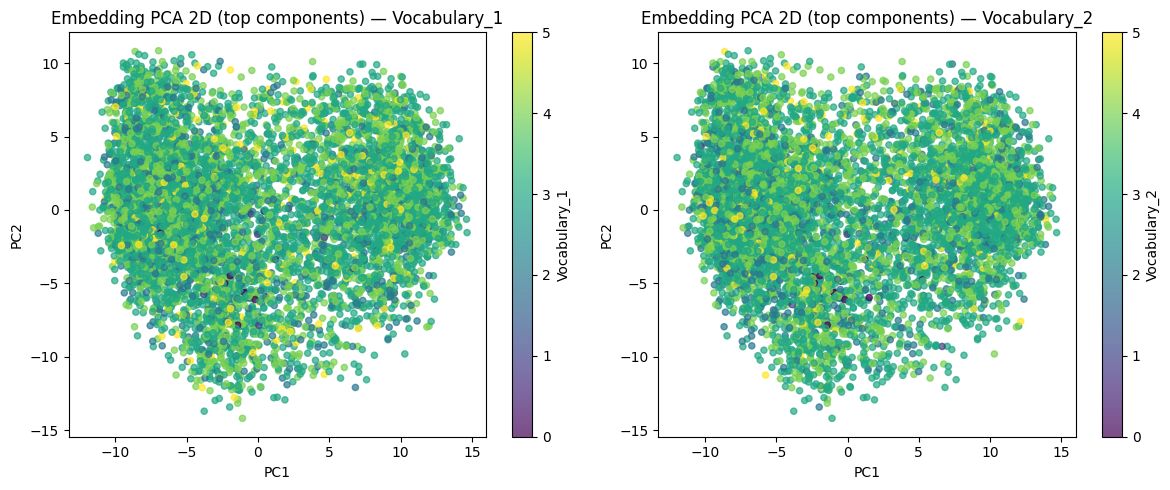

In [30]:
# Scatter: 2D from top-50-by-correlation subspace, colored by Vocabulary_1 and Vocabulary_2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_embedding_scatter_2d(X_2d, df, "Vocabulary_1", title="Embedding PCA 2D (top components) — Vocabulary_1", ax=ax1)
plot_embedding_scatter_2d(X_2d, df, "Vocabulary_2", title="Embedding PCA 2D (top components) — Vocabulary_2", ax=ax2)
plt.tight_layout()
plt.show()

### 2.9 Clustering

KMeans on embedding vectors; per-cluster mean of Vocabulary_1 and Vocabulary_2.

In [31]:
cluster_labels = get_embedding_kmeans_labels(embeddings, n_clusters=6)
cluster_summary = get_cluster_target_summary(cluster_labels, df, ["Vocabulary_1", "Vocabulary_2"])
cluster_summary

,count,Vocabulary_1_mean,Vocabulary_2_mean
cluster,,,
0,917,3.125409,3.101418
1,1851,3.264182,3.241491
2,661,3.372163,3.290469
3,1585,3.261199,3.197476
4,1702,3.230317,3.276733
5,396,3.351010,3.328283


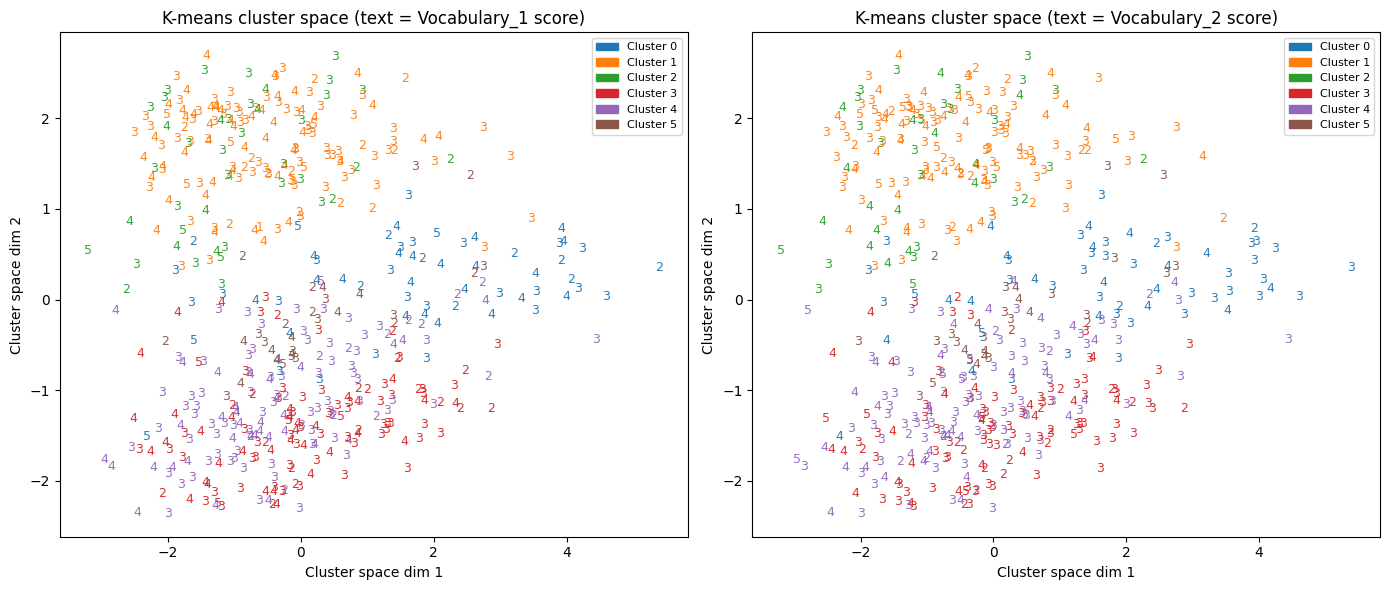

In [32]:
# K-means cluster space (2D from distances to centroids). Color = cluster, text = score. Subsampled so digits are readable.
X_2d_cluster = get_cluster_space_2d(embeddings, cluster_labels)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
scores_v1 = df["Vocabulary_1"].iloc[: len(X_2d_cluster)].values
scores_v2 = df["Vocabulary_2"].iloc[: len(X_2d_cluster)].values
plot_cluster_space_score_labels(
    X_2d_cluster, cluster_labels, scores_v1,
    title="K-means cluster space (text = Vocabulary_1 score)", ax=ax1,
    subsample=500, fontsize=9,
)
plot_cluster_space_score_labels(
    X_2d_cluster, cluster_labels, scores_v2,
    title="K-means cluster space (text = Vocabulary_2 score)", ax=ax2,
    subsample=500, fontsize=9,
)
plt.tight_layout()
plt.show()

### 2.10 Summary

Handcrafted features ranked by mean absolute correlation with Vocabulary_1 and Vocabulary_2.

In [33]:
summary_corr = get_handcrafted_feature_ranked_correlations(
    length_features,
    richness_features,
    pos_ratios,
    readability_df,
    df,
    ["Vocabulary_1", "Vocabulary_2"],
    method="spearman",
)
summary_corr

,Vocabulary_1,Vocabulary_2,|corr|_mean
unique_words,0.369529,0.343492,0.356511
sentence_count,0.323853,0.290548,0.307200
char_count,0.309345,0.288554,0.298949
word_count,0.289057,0.268695,0.278876
avg_word_length,0.183857,0.189495,0.186676
adv_ratio,0.069208,0.079064,0.074136
hapax_ratio,0.077281,0.064578,0.070929
flesch_kincaid_grade,-0.086040,-0.054574,0.070307
other_ratio,-0.038413,-0.035857,0.037135
ttr,-0.022685,-0.012597,0.017641


### 2.11 Distribution of top 4 handcrafted features

Histograms for the top 4 features by correlation with the targets (unique_words, sentence_count, char_count, word_count). Use these to decide transformations (e.g. log, sqrt) before modeling.

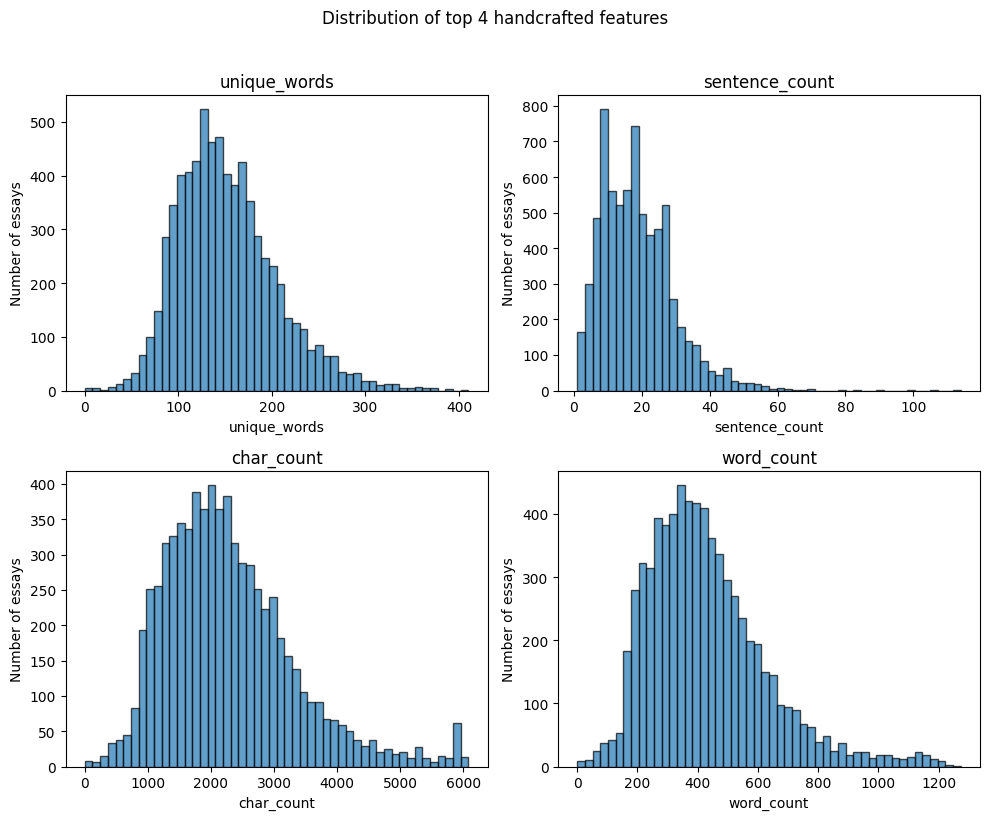

In [34]:
# Top 4 features: one distribution plot per feature (modular)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_feature_distribution(richness_features["unique_words"], ax=axes[0, 0])
plot_feature_distribution(length_features["sentence_count"], ax=axes[0, 1])
plot_feature_distribution(length_features["char_count"], ax=axes[1, 0])
plot_feature_distribution(length_features["word_count"], ax=axes[1, 1])
fig.suptitle("Distribution of top 4 handcrafted features", y=1.02)
plt.tight_layout()
plt.show()